# Data Exploration

This notebook provides exploratory analysis of the CanESM5 climate data:
1. Surface temperature (tas) patterns and trends
2. TOA radiation budget (rsdt, rsut, rlut)
3. Cloud Radiative Effects (CRE)

In [ ]:
import sys
sys.path.append('..')


from utils import (
    load_dataset,
    plot_spatial_map,
    plot_zonal_mean
)

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

## Surface Temperature (tas) Analysis

In [2]:
# Load surface temperature data
tas_ds = load_dataset("../../data/CanESM5_historical_tas.nc")

print("Dataset overview:")
print(tas_ds)
print("\nDimensions:", tas_ds.dims)
print("Coordinates:", list(tas_ds.coords))
print("Data variables:", list(tas_ds.data_vars))


Dataset overview:
<xarray.Dataset> Size: 2GB
Dimensions:    (member: 25, time: 1980, bnds: 2, lat: 64, lon: 128)
Coordinates:
  * member     (member) int64 200B 0 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat        (lat) float64 512B -87.86 -85.1 -82.31 ... 82.31 85.1 87.86
  * lon        (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (member, time, bnds) object 792kB ...
    lat_bnds   (member, lat, bnds) float64 26kB ...
    lon_bnds   (member, lon, bnds) float64 51kB ...
    tas        (member, time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CCCma_model_hash:            8ac7a3c953a92eb65289508ded4d1b280d2bae9e
    CCCma_parent_runid:          p2-pictrl
    CCCma_pycmor_hash:           33c30511acc319a98240633965a04ca99c26427e
    CCCma_runid:                 p2-his01
    Convention

C:\Users\usuario\AppData\Local\Temp\ipykernel_10108\3976931723.py:3: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  da = da.assign_coords(time=da.indexes["time"].to_datetimeindex())
C:\Users\usuario\AppData\Local\Temp\ipykernel_10108\3976931723.py:3: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  da = da.assign_coords(time=da.indexes["time"].to_datetimeindex())


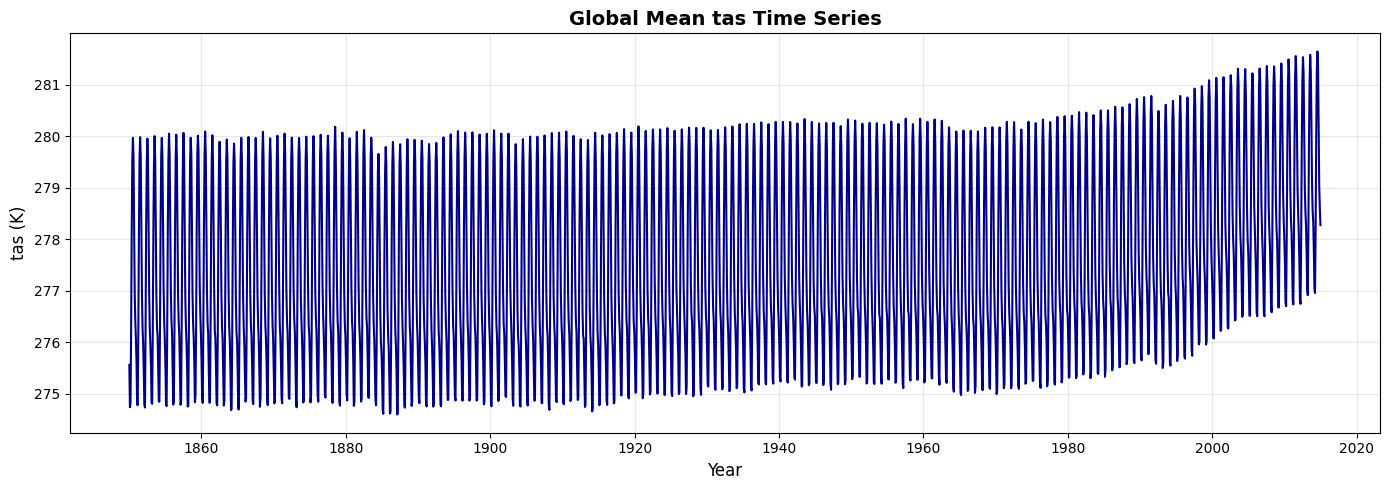

In [3]:
var_name = "tas"
da = tas_ds[var_name]
da = da.assign_coords(time=da.indexes["time"].to_datetimeindex())


# Plot a spatial mean time series (if time exists)
if "time" in da.dims:
    spatial_dims = [d for d in da.dims if d != "time"]
    if spatial_dims:
        time_series = da.mean(spatial_dims)
        
        # Create a clear, professional-looking plot
        fig, ax = plt.subplots(figsize=(14, 5))
        time_series.plot(ax=ax, linewidth=1.5, color="darkblue")
        
        ax.set_xlabel("Year", fontsize=12)
        ax.set_ylabel(f"{var_name} (K)", fontsize=12)
        ax.set_title(f"Global Mean {var_name} Time Series", fontsize=14, fontweight="bold")
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


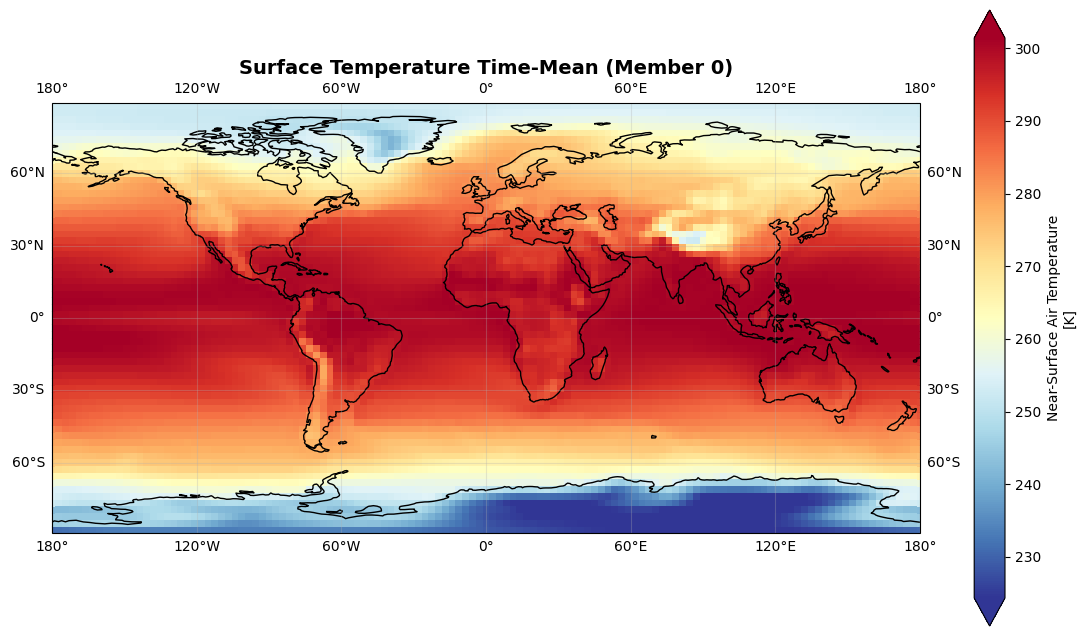

In [7]:
# Plot spatial pattern (time-mean)
plot_spatial_map(
    da,
    title="Surface Temperature Time-Mean (Member 0)",
    cmap="RdYlBu_r"
)
plt.show()

## TOA Radiation Budget

Analyze the Top-of-Atmosphere radiation balance:
- **rsdt**: Incoming solar radiation
- **rsut**: Outgoing reflected solar radiation  
- **rlut**: Outgoing thermal radiation
- **Net TOA**: rsdt - rsut - rlut

In [8]:
# Load TOA radiation components
rsdt = load_dataset("../../data/CanESM5_hist_rsdt.nc")["rsdt"]
rsut = load_dataset("../../data/CanESM5_hist_rsut.nc")["rsut"]
rlut = load_dataset("../../data/CanESM5_hist_rlut.nc")["rlut"]

# Align datasets
rsdt, rsut, rlut = xr.align(rsdt, rsut, rlut)

# Compute net TOA radiation
net_toa = rsdt - rsut - rlut
net_toa.attrs['long_name'] = 'Net TOA Radiation'
net_toa.attrs['units'] = 'W/m^2'

print("Net TOA radiation computed")
print(net_toa)

Net TOA radiation computed
<xarray.DataArray (member: 25, time: 1980, lat: 64, lon: 128)> Size: 2GB
array([[[[ -31.331879,  -31.513565,  -31.646866, ...,  -30.636734,
           -30.765137,  -30.879303],
         [ -30.062805,  -29.53357 ,  -30.109268, ...,  -31.501633,
           -30.504425,  -30.079727],
         [ -30.936813,  -30.485443,  -30.452087, ...,  -31.350174,
           -30.769135,  -31.306763],
         ...,
         [-170.18501 , -171.40823 , -172.62355 , ..., -167.22023 ,
          -168.32422 , -169.3624  ],
         [-163.81276 , -163.92891 , -164.20201 , ..., -162.845   ,
          -163.14824 , -163.19633 ],
         [-158.84091 , -158.88884 , -158.8951  , ..., -158.63293 ,
          -158.82306 , -158.87714 ]],

        [[ -70.805374,  -70.45918 ,  -70.309906, ...,  -71.56268 ,
           -71.24486 ,  -70.98067 ],
         [ -71.74466 ,  -70.8183  ,  -70.39676 , ...,  -75.01372 ,
           -73.68027 ,  -72.563095],
         [ -72.10239 ,  -71.56041 ,  -71.12138 , ...

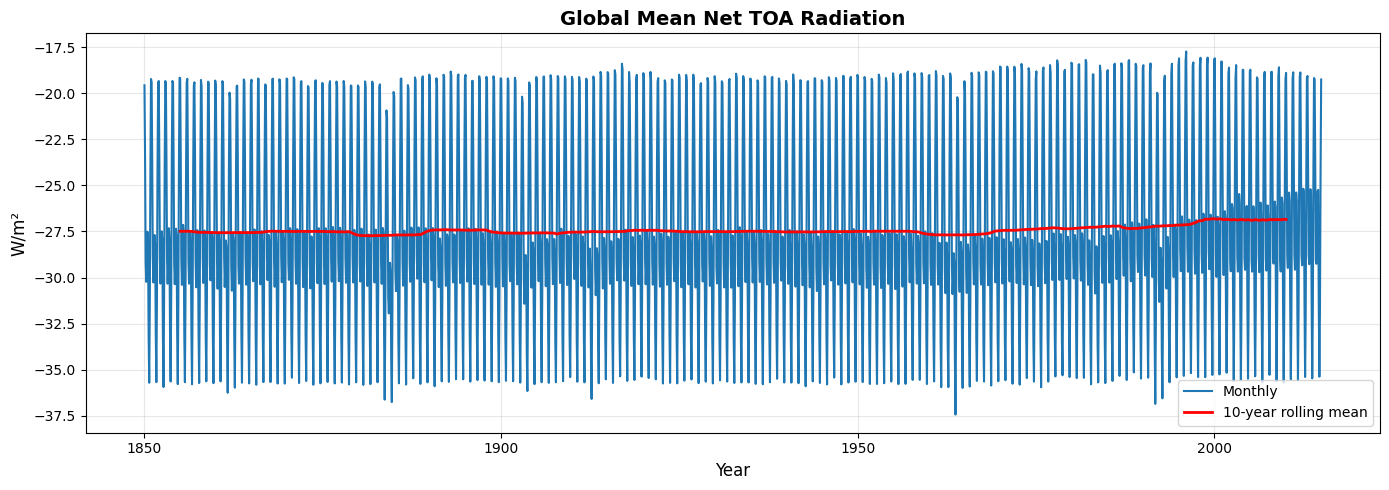

Trend: 0.00325 W/m² per year


In [9]:
# Plot global mean net TOA with trend
global_mean = net_toa.mean(dim=["lat", "lon"])
if "member" in global_mean.dims:
    global_mean = global_mean.mean(dim="member")

years = global_mean["time"].dt.year + (global_mean["time"].dt.month - 1) / 12

# Compute linear trend
coeffs = np.polyfit(years, global_mean.values, 1)
trend_line = np.polyval(coeffs, years)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
global_mean.plot(ax=ax, label="Monthly")

# Rolling mean
global_mean_smooth = global_mean.rolling(time=120, center=True).mean()
global_mean_smooth.plot(ax=ax, color="red", linewidth=2, label="10-year rolling mean")

ax.set_title("Global Mean Net TOA Radiation", fontsize=14, fontweight="bold")
ax.set_ylabel("W/m²", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trend: {coeffs[0]:.5f} W/m² per year")

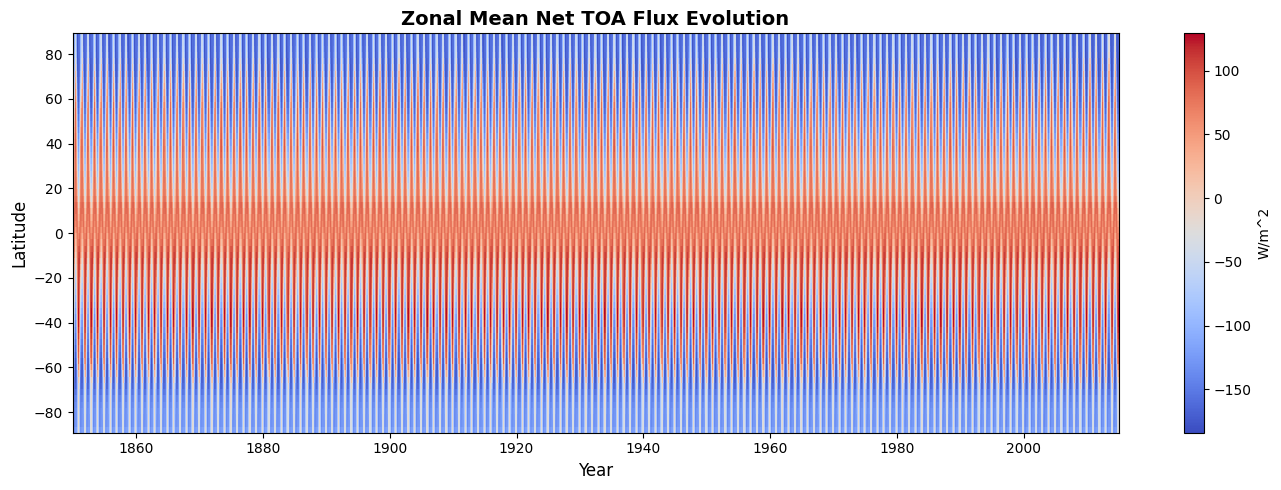

In [10]:
# Plot zonal mean evolution
plot_zonal_mean(
    net_toa,
    title="Zonal Mean Net TOA Flux Evolution"
)
plt.show()

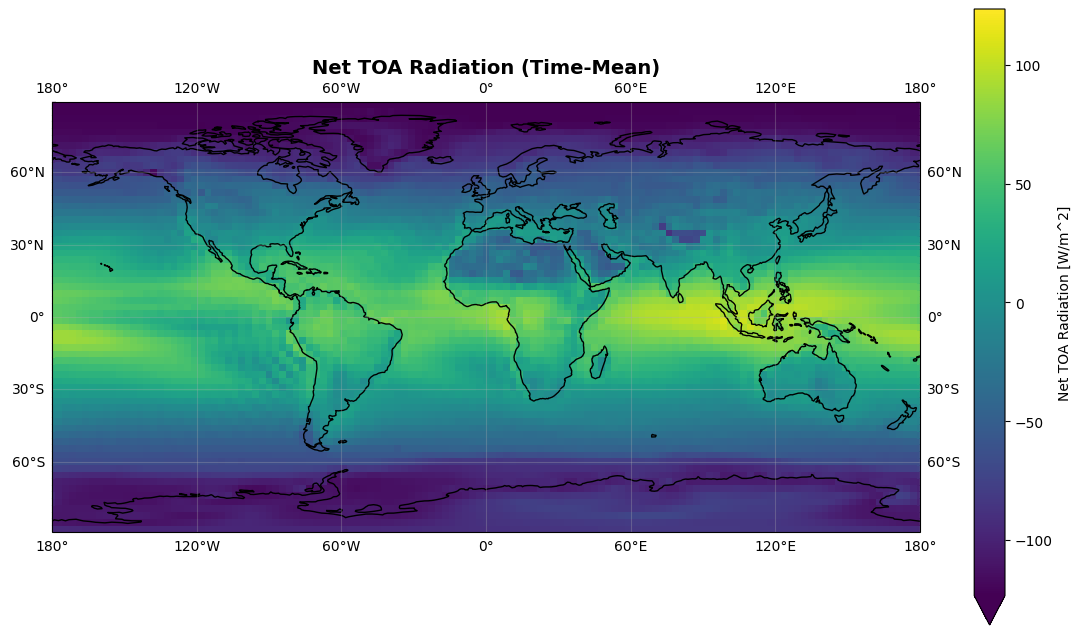

In [11]:
# Plot spatial pattern
plot_spatial_map(
    net_toa,
    title="Net TOA Radiation (Time-Mean)",
    cmap="viridis"
)
plt.show()

## Cloud Radiative Effects

Explore the impact of clouds on radiation budget.

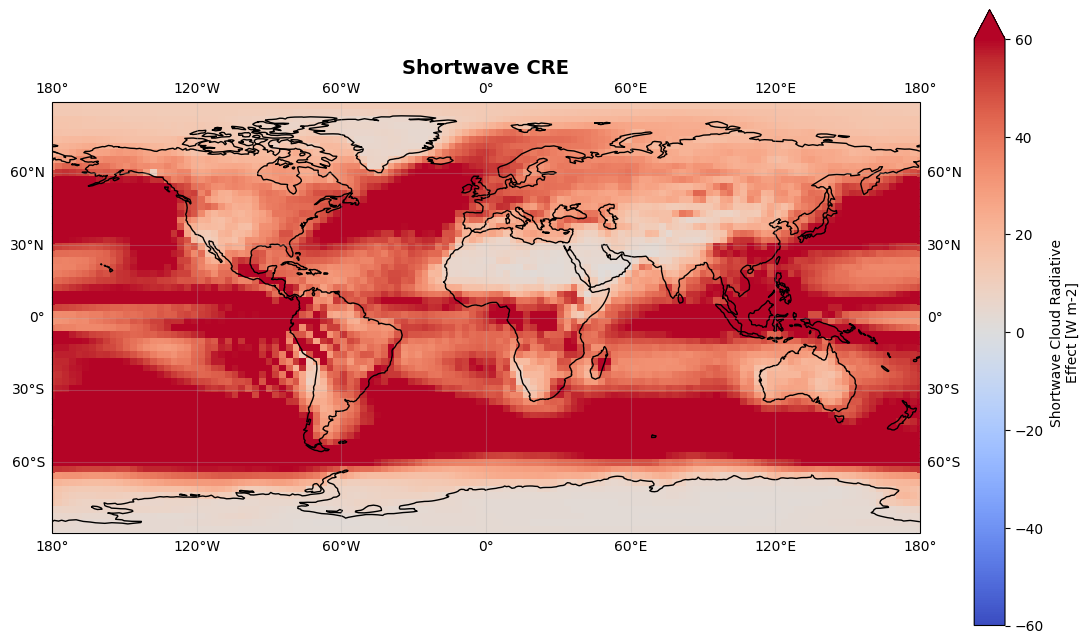

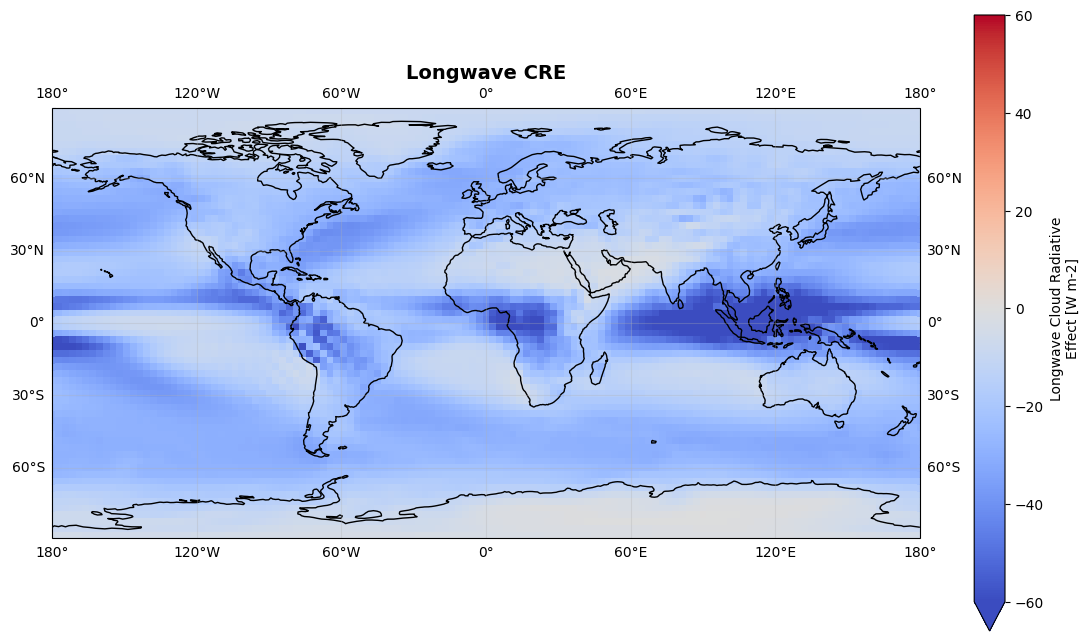

In [ ]:

swcre = load_dataset("../../data/CanESM5_1850-2100_rsutcre.nc")["cre"]
lwcre = load_dataset("../../data/CanESM5_1850-2100_rlutcre.nc")["cre"]

plot_spatial_map(swcre, title="Shortwave CRE", vmin=-60, vmax=60)
plt.show()

plot_spatial_map(lwcre, title="Longwave CRE", vmin=-60, vmax=60)
plt.show()